## Boosting in Supervised Machine Learning

**Boosting** is an ensemble learning technique that aims to improve the prediction accuracy of a weak learner (typically a decision tree, often referred to as a "stump" if it's a very shallow tree) by sequentially building a series of models. The core idea is to train subsequent models to focus on the mistakes made by previous models, thereby progressively reducing bias and variance.

### How Boosting Works:

1.  **Initial Model:** A base model (weak learner) is trained on the original dataset.
2.  **Weighted Data:** After the first model makes predictions, the data points that were misclassified or had higher errors are given increased weights (or their importance is emphasized).
3.  **Sequential Training:** A new base model is trained on this re-weighted dataset, paying more attention to the previously misclassified examples.
4.  **Iteration:** Steps 2 and 3 are repeated for a specified number of iterations. Each new model tries to correct the errors of the previous ones.
5.  **Final Prediction:** The predictions from all the individual base models are combined, usually through a weighted average (for regression) or a weighted majority vote (for classification), to produce the final, strong prediction.

### Key Concepts:

*   **Weak Learners:** Simple models that perform slightly better than random guessing. Decision trees, especially shallow ones, are commonly used.
*   **Sequential Learning:** Models are built one after another, with each new model learning from the errors of its predecessors.
*   **Adaptive Weighting:** The process of adjusting data point weights (or focusing on residuals) to highlight challenging examples.
*   **Bias-Variance Trade-off:** Boosting primarily aims to reduce bias (underfitting) by iteratively improving the model's ability to fit the training data. While it can reduce variance, it's generally more focused on bias reduction compared to bagging methods like Random Forests.

### Popular Boosting Algorithms:

1.  **AdaBoost (Adaptive Boosting):**
    *   One of the earliest and most influential boosting algorithms.
    *   It re-weights training instances at each iteration, giving higher weights to misclassified examples.
    *   The final prediction is a weighted sum of the weak learners' predictions, where learners that perform better are given higher weights.

2.  **Gradient Boosting (e.g., Gradient Boosting Machines - GBM):**
    *   Instead of re-weighting data points, GBMs train subsequent models on the **residuals** (the errors) of the previous models.
    *   Each new tree tries to predict the residual errors made by the ensemble so far.
    *   It uses gradient descent to minimize the loss function.

3.  **XGBoost (eXtreme Gradient Boosting):**
    *   An optimized and highly efficient implementation of gradient boosting.
    *   Includes regularization (L1 and L2) to prevent overfitting.
    *   Supports parallel processing and handles missing values internally.
    *   Widely popular in Kaggle competitions due to its speed and performance.

4.  **LightGBM (Light Gradient Boosting Machine):**
    *   Another high-performance gradient boosting framework.
    *   Uses a leaf-wise (rather than level-wise) tree growth algorithm, which can lead to faster training and better accuracy for certain datasets.
    *   Optimized for large datasets.

5.  **CatBoost (Categorical Boosting):**
    *   A gradient boosting library that excels at handling categorical features automatically.
    *   Uses a novel algorithm to prevent prediction shift and provides robust out-of-the-box performance.

### Advantages of Boosting:

*   **High Accuracy:** Often achieves state-of-the-art performance on a wide range of supervised learning tasks.
*   **Reduces Bias:** By iteratively correcting errors, boosting models are very good at capturing complex relationships in the data.
*   **Versatility:** Can be used for both classification and regression problems.

### Disadvantages of Boosting:

*   **Prone to Overfitting:** Since models are built sequentially and focus on errors, boosting can be sensitive to noisy data and outliers, potentially leading to overfitting if not carefully tuned.
*   **Computationally Intensive:** Sequential nature makes it harder to parallelize compared to bagging methods.
*   **Requires Tuning:** Many hyperparameters need to be tuned for optimal performance.

### When to Use Boosting:

Boosting is a powerful technique for tasks where high predictive accuracy is crucial and you have sufficient computational resources. It's particularly effective when dealing with complex datasets and can often outperform other algorithms if well-tuned.

## AdaBoost (Adaptive Boosting)

**AdaBoost** (short for Adaptive Boosting) is one of the earliest and most popular boosting algorithms, introduced by Yoav Freund and Robert Schapire in 1995. It's primarily used for classification tasks, though adaptations for regression exist. The core idea behind AdaBoost is to combine many "weak learners" (models that perform slightly better than random chance) to create a single "strong learner" that can make accurate predictions.

### How AdaBoost Works (for Binary Classification):

1.  **Initialize Weights:**
    *   Initially, all training data points are assigned equal weights. If there are `N` data points, each gets a weight of `1/N`. These weights are used to emphasize certain data points during the training of subsequent weak learners.

2.  **Iterative Training of Weak Learners:**
    *   For a specified number of iterations (or until a desired accuracy is reached), AdaBoost sequentially trains a series of weak learners (typically decision stumps, which are one-level decision trees).

    *   **Train a Weak Learner:** A weak learner `h_t(x)` is trained on the training data, taking into account the current weights of the data points. The goal of this weak learner is to minimize the weighted error.

    *   **Calculate Error Rate:** The error rate (`epsilon_t`) of the weak learner `h_t(x)` is calculated as the sum of weights of the misclassified training examples.
        `epsilon_t = sum(w_i * I(y_i != h_t(x_i))) / sum(w_i)` where `I` is the indicator function.

    *   **Calculate Learner Weight (`alpha_t`):** A weight (`alpha_t`) is assigned to the weak learner `h_t(x)` based on its accuracy. More accurate learners get higher weights.
        `alpha_t = 0.5 * log((1 - epsilon_t) / epsilon_t)`. This ensures that if a learner performs well (low `epsilon_t`), its `alpha_t` is large and positive, and if it performs poorly (high `epsilon_t` close to 0.5), its `alpha_t` is small or negative.

    *   **Update Data Weights:** The weights of the training data points are updated for the next iteration:
        *   **Misclassified points:** The weights of misclassified data points are increased. This forces the next weak learner to focus more on these difficult examples.
        *   **Correctly classified points:** The weights of correctly classified data points are decreased.
        *   The new weights are then normalized so that they sum up to 1.
        `w_{i,t+1} = w_{i,t} * exp(-alpha_t * y_i * h_t(x_i))`
        Then, normalize: `w_{i,t+1} = w_{i,t+1} / sum(w_{j,t+1})`

3.  **Combine Weak Learners:**
    *   After all iterations, the final strong learner `H(x)` is a weighted sum of all the individual weak learners:
        `H(x) = sign(sum(alpha_t * h_t(x)))`
    *   The `sign` function is used for binary classification to assign the final class label.

### Key Characteristics of AdaBoost:

*   **Focuses on Hard Examples:** By increasing the weights of misclassified data points, AdaBoost adaptively focuses on the examples that are difficult to classify, forcing subsequent models to learn from these mistakes.
*   **Sequential Learning:** It's a sequential process where each weak learner is influenced by the performance of the previous ones.
*   **Adaptive Combination:** Weak learners are combined with weights proportional to their accuracy, giving more influence to better-performing models.
*   **Weak Learners are Simple:** Typically uses very simple models (e.g., decision stumps) to keep individual models weak and ensure that the ensemble benefits from diversity.

### Advantages of AdaBoost:

*   **Simple to Implement:** The core algorithm is relatively straightforward.
*   **Robust:** Less prone to overfitting compared to some other boosting algorithms if the number of weak learners is not excessively large.
*   **No Hyperparameter Tuning for Weak Learners:** Often uses decision stumps, which don't require much tuning.
*   **Effective:** Can achieve very high accuracy and is considered a strong baseline for many classification tasks.

### Disadvantages of AdaBoost:

*   **Sensitive to Noisy Data/Outliers:** Because it focuses heavily on misclassified examples, noisy data or outliers can be given extremely high weights, leading to the model trying to fit the noise and potentially overfitting.
*   **Computationally Intensive:** Sequential training means it can be slower than parallelizable algorithms.

### Applications:

AdaBoost has been successfully applied in various fields, including:
*   **Face Detection:** The Viola-Jones object detection framework, famous for real-time face detection, uses AdaBoost with Haar-like features.
*   **Image Recognition:** For classifying objects in images.
*   **Bioinformatics:** For classifying biological data.

AdaBoost laid the foundation for many subsequent, more advanced boosting algorithms like Gradient Boosting Machines (GBM), XGBoost, LightGBM, and CatBoost.

## Python Example: AdaBoost with Scikit-learn

This example demonstrates how to use `AdaBoostClassifier` from scikit-learn for a binary classification task. We'll use a synthetic dataset for illustration.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Generate a synthetic dataset
X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (210, 2), (210,)
Testing data shape: (90, 2), (90,)


Let's visualize the synthetic dataset to understand its structure.

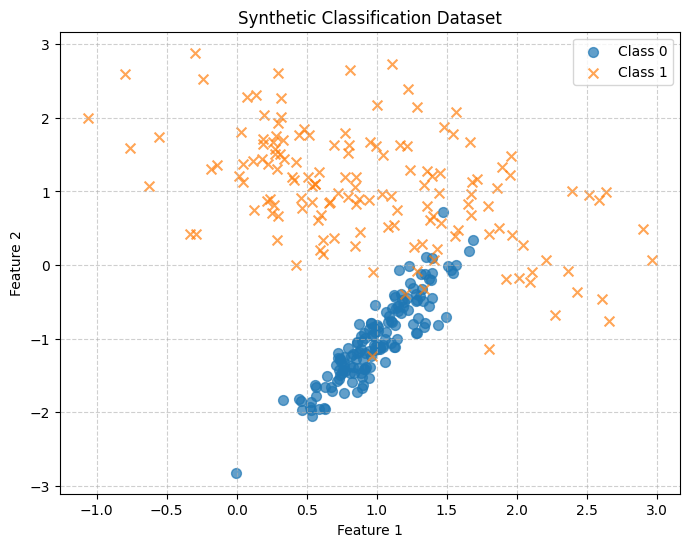

In [ ]:
# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0', marker='o', s=50, alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1', marker='x', s=50, alpha=0.7)
plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Now, let's train the AdaBoost Classifier. We'll use a `DecisionTreeClassifier` with `max_depth=1` (a decision stump) as the base estimator, which is a common choice for AdaBoost.

In [ ]:
# 2. Initialize and train the AdaBoostClassifier
# We use a DecisionTreeClassifier with max_depth=1 (decision stump) as the base estimator
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,  # Number of weak learners (stumps) to train
    learning_rate=1.0, # Contribution of each weak learner
    random_state=42
)

adaboost_model.fit(X_train, y_train)

print("AdaBoost model training complete.")

AdaBoost model training complete.


After training, we can evaluate the model's performance on the test set.

In [ ]:
# 3. Make predictions on the test set
y_pred = adaboost_model.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy on the test set: 0.9556

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.98      0.93      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



Finally, let's visualize the decision boundary learned by the AdaBoost model.

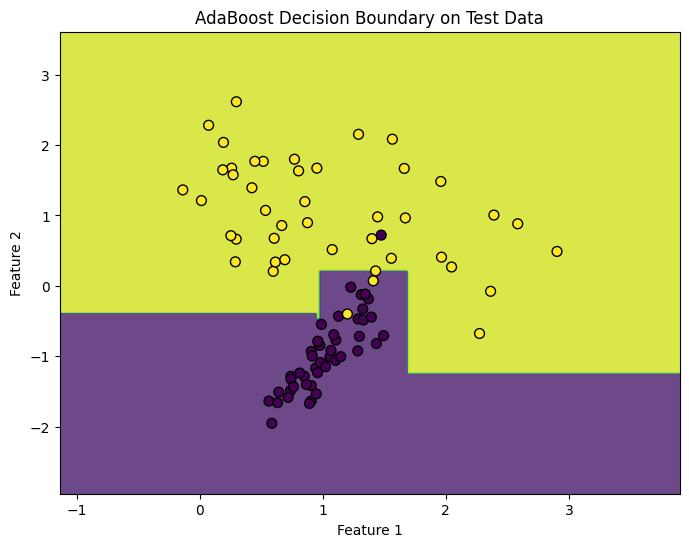

In [ ]:
# 5. Visualize the decision boundary

def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                           np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_decision_boundary(X_test, y_test, adaboost_model, 'AdaBoost Decision Boundary on Test Data')

# Classification Programs

# 1. AdaBoost Classifier - Iris Classification


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 1. Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 0.9666666666666667


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#. Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
#  Predict New Flower
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("\nPredicted Flower:",
      iris.target_names[prediction[0]])


Predicted Flower: setosa


# Breast Cancer Classification

In [ ]:

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# 1. Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [ ]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# 3. Create Model
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)


In [ ]:

# 4. Train
model.fit(X_train, y_train)

# 5. Prediction
y_pred = model.predict(X_test)


In [ ]:
# 5. Prediction
y_pred = model.predict(X_test)

In [ ]:
# 6. Accuracy
print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

# 7. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 8. Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)



Accuracy: 0.956140350877193

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# 9. Sample Prediction
sample = [X_test[0]]

prediction = model.predict(sample)

print("\nPredicted Class:",
      data.target_names[prediction[0]])

print("Actual Class:",
      data.target_names[y_test[0]])


Predicted Class: malignant
Actual Class: malignant


# 3.Titanic Survival Prediction

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# 1. Load Dataset
df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())

print("\nShape:", df.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

S

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:

# 2. Select Useful Features
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]


In [ ]:
X = df[features].copy()

y = df["Survived"]

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# 3. Handle Missing Values

X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

X["Fare"] = X["Fare"].fillna(
    X["Fare"].median()
)

X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)


In [ ]:

# 4. Convert Categorical Variables

X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)


In [ ]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# 6. Create AdaBoost Model
model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)


AdaBoostClassifier(learning_rate=0.5, n_estimators=100, random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

# 10. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 11. Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# 12. Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)



Accuracy: 0.7877094972067039

Confusion Matrix:
[[91 19]
 [19 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       110
           1       0.72      0.72      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [ ]:

print("\nFeature Importance:")
print(importance)


Feature Importance:
      Feature  Importance
4        Fare    0.343979
5    Sex_male    0.200565
1         Age    0.191465
0      Pclass    0.110497
2       SibSp    0.080093
3       Parch    0.048241
7  Embarked_S    0.025159
6  Embarked_Q    0.000000


# AdaBoost Regression

## AdaBoost Regressor

**AdaBoost Regressor** is an extension of the AdaBoost algorithm adapted for regression tasks. Similar to its classification counterpart, it works by combining the predictions of several weak learners to form a strong predictor. The core idea remains the same: sequentially train models, with each new model focusing on correcting the errors of the previous ones.

### How AdaBoost Regressor Works:

1.  **Initialize Weights:** All training data points are initially assigned equal weights.

2.  **Iterative Training of Weak Learners:**
    *   For a specified number of iterations, a weak learner (often a decision tree, but for regression, it's typically a regression tree) is trained on the training data, taking into account the current weights of the data points.
    *   **Calculate Error:** Unlike classification where misclassified points are identified, in regression, the error is typically measured by the difference between the true and predicted values (e.g., squared error, absolute error).
    *   **Calculate Learner Weight:** A weight is assigned to the weak learner based on its performance. More accurate learners (those with lower errors) receive higher weights.
    *   **Update Data Weights:** The weights of the training data points are updated. Data points that were poorly predicted by the current weak learner (i.e., had large errors) are given increased weights. This forces the next weak learner to pay more attention to these difficult-to-predict examples. The weights are then normalized.

3.  **Combine Weak Learners:** The final prediction is a weighted sum of the predictions from all individual weak learners. Learners that performed better during their training (and thus received higher weights) contribute more to the final prediction.

### Key Differences from AdaBoost Classifier:

*   **Error Calculation:** For classification, error is based on misclassification rate. For regression, it's based on a loss function (e.g., linear, square, exponential loss) that quantifies the difference between actual and predicted values.
*   **Weak Learners:** While decision stumps are common for classification, regression often uses regression trees, and their `max_depth` can be varied.
*   **Weight Update:** The method for updating instance weights is modified to account for regression errors, rather than binary misclassifications.

### Advantages:

*   Can achieve high accuracy by combining multiple weak learners.
*   Focuses on hard-to-predict instances, which can improve performance on complex datasets.
*   Relatively robust to overfitting if parameters are well-tuned.

### Disadvantages:

*   Sensitive to noisy data and outliers, as these instances will receive higher weights.
*   Can be computationally intensive due to its sequential nature.
*   Requires careful tuning of hyperparameters like `n_estimators`, `learning_rate`, and the base estimator's parameters (`max_depth`).

### Common Use Cases:

AdaBoost Regressor is useful in scenarios where you need to predict continuous values and want to build a robust model by leveraging an ensemble of simpler predictors. It's often applied in fields like finance, engineering, and predictive maintenance.

Let's demonstrate AdaBoost Regressor using `scikit-learn` with a synthetic dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate a synthetic dataset for regression
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.5, X.shape[0])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (70, 1), (70,)
Testing data shape: (30, 1), (30,)


In [2]:
# 2. Initialize and train the AdaBoostRegressor
# We use a DecisionTreeRegressor as the base estimator
base_estimator = DecisionTreeRegressor(max_depth=4, random_state=42)

adaboost_regressor = AdaBoostRegressor(
    estimator=base_estimator,
    n_estimators=100,  # Number of weak learners
    learning_rate=0.1, # Contribution of each weak learner
    loss='linear',     # 'linear', 'square', or 'exponential'
    random_state=42
)

adaboost_regressor.fit(X_train, y_train)

print("AdaBoost Regressor model training complete.")

AdaBoost Regressor model training complete.


Mean Squared Error on the test set: 0.2321
R-squared score on the test set: 0.6109


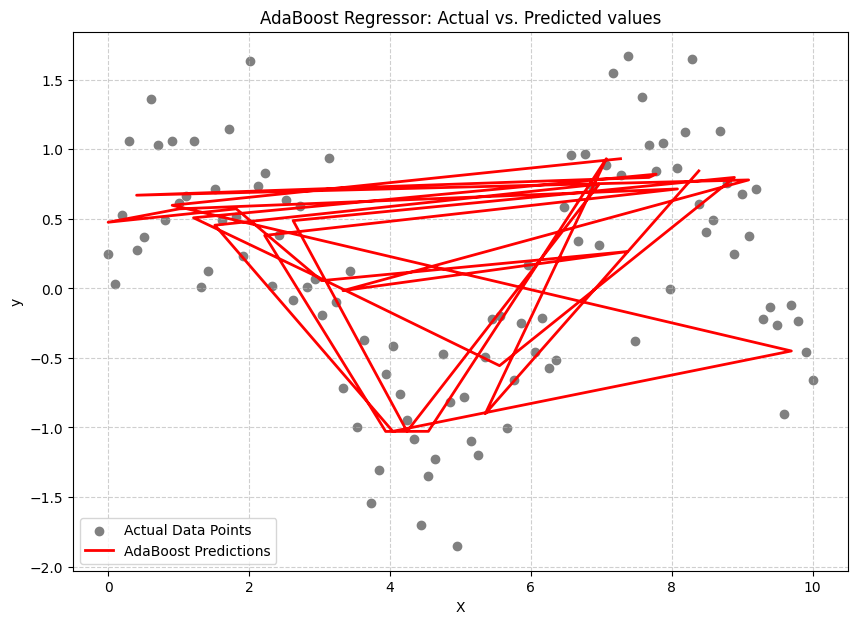

In [3]:
# 3. Make predictions on the test set
y_pred = adaboost_regressor.predict(X_test)

# 4. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error on the test set: {mse:.4f}")
print(f"R-squared score on the test set: {r2:.4f}")

# 5. Visualize the predictions
plt.figure(figsize=(10, 7))
plt.scatter(X, y, c='gray', label='Actual Data Points')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='AdaBoost Predictions')
plt.title('AdaBoost Regressor: Actual vs. Predicted values')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2.California housing prices.

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
data=fetch_california_housing()

In [6]:
X=data.data
y=data.target

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Base estimator
base_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

In [10]:
model = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

In [11]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.543883194079257
RMSE: 0.7044120320399936
R2 Score: 0.621342405980147


# Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("\nLinear Regression")
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R2:", r2_score(y_test, linear_pred))


Linear Regression
MAE: 0.533200130495698
RMSE: 0.7455813830127749
R2: 0.5757877060324524


# Decision Tree

In [14]:
tree_model = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("\nDecision Tree")
print("MAE:", mean_absolute_error(y_test, tree_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_pred)))
print("R2:", r2_score(y_test, tree_pred))


Decision Tree
MAE: 0.5587407879847646
RMSE: 0.7644636017038845
R2: 0.5540288505085005


# Random Forest

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))


Random Forest
MAE: 0.5320316153003126
RMSE: 0.7255925029973709
R2: 0.5982288818619471


# 3. AdaBoost Regression — Diabetes Dataset

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
# Load dataset
data = load_diabetes()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Base learner
base_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

In [19]:
model=AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

In [20]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 43.094971803613134
RMSE: 52.75792334666962
R2 Score: 0.4746472717335106


# AdaBoost with Different Learning Rates

In [22]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

learning_rates = [
    0.01,
    0.05,
    0.1,
    0.2,
    0.5,
    1.0
]

for lr in learning_rates:

    model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(
            max_depth=3,
            random_state=42
        ),
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(
        "Learning Rate:", lr,
        "R2:", r2_score(y_test, y_pred)
    )

Learning Rate: 0.01 R2: 0.4885633093926879
Learning Rate: 0.05 R2: 0.4746472717335106
Learning Rate: 0.1 R2: 0.4669159016495442
Learning Rate: 0.2 R2: 0.453329667984262
Learning Rate: 0.5 R2: 0.451693044759072
Learning Rate: 1.0 R2: 0.4052324024394999


#  AdaBoost + Random Forest Comparison

In [23]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    AdaBoostRegressor,
    RandomForestRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:

# AdaBoost
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

In [25]:

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [26]:

print("AdaBoost")
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, ada_pred))
)
print("R2:", r2_score(y_test, ada_pred))


print("\nRandom Forest")
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, rf_pred))
)
print("R2:", r2_score(y_test, rf_pred))

AdaBoost
RMSE: 52.75792334666962
R2: 0.4746472717335106

Random Forest
RMSE: 53.03554583023371
R2: 0.46910370728842354
